In [135]:
import pandas as pd
import numpy as np
import seaborn as sns

In [136]:
df = pd.read_csv('/home/shiva/Datasets/V2_01_easy/V2_01_easy/mav0/imu0/data.csv')

In [137]:
df

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1738007543152990976,0.009587,-0.004261,-0.002131,-9.47146,-0.03831,-2.08774
1,1738007543157788928,0.011718,-0.003196,-0.002131,-9.46404,-0.04202,-2.10044
2,1738007543162704896,0.017044,0.000000,-0.006392,-9.45321,-0.04743,-2.13292
3,1738007543167581184,0.010653,0.001065,-0.003196,-9.45386,-0.04788,-2.13676
4,1738007543172961024,0.013848,0.000000,-0.001065,-9.43316,-0.03788,-2.15102
...,...,...,...,...,...,...,...
14214,1738007614196130048,-0.009587,0.008522,0.034088,-9.40759,0.37069,-3.03866
14215,1738007614201165824,-0.006392,0.004261,0.031958,-9.36941,0.33818,-3.04481
14216,1738007614206226944,-0.009587,0.002131,0.030893,-9.37512,0.32676,-3.01056
14217,1738007614210818048,-0.011718,0.002131,0.029827,-9.36215,0.35668,-2.99357


<Axes: xlabel='position', ylabel='delta'>

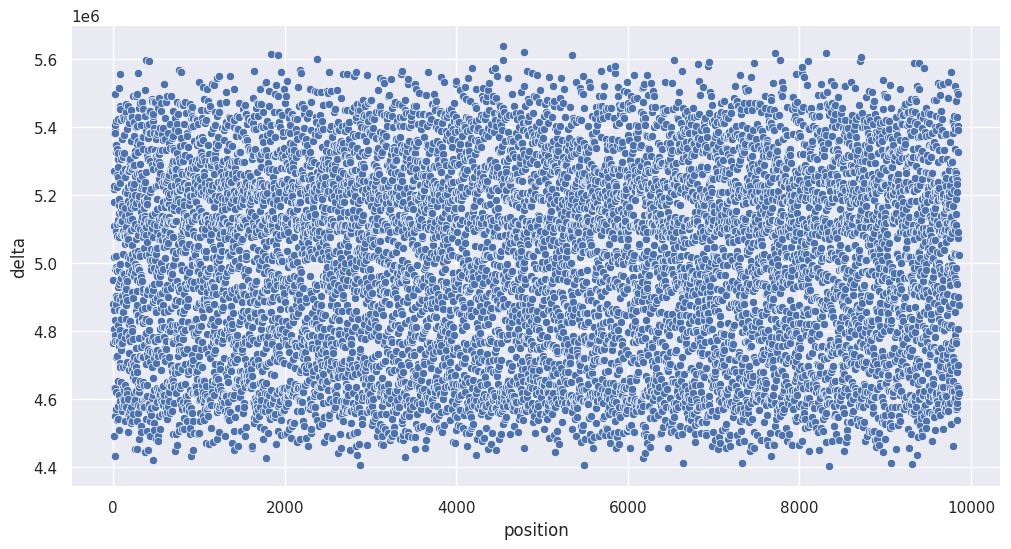

In [98]:
deltas = np.diff(df['#timestamp [ns]'])
delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
sns.set_theme(rc={'figure.figsize':(12, 6)})
sns.scatterplot(data=delta_df, x='position', y='delta')

In [99]:
delta_df.describe()

,position,delta
count,9858.000000,9.858000e+03
mean,4928.500000,4.997850e+06
std,2845.903811,2.844808e+05
min,0.000000,4.401920e+06
25%,2464.250000,4.753152e+06
50%,4928.500000,5.017088e+06
75%,7392.750000,5.227008e+06
max,9857.000000,5.637120e+06


In [118]:
df = pd.read_csv('/home/shiva/Datasets/V2_01_easy/V2_01_easy/mav0/cam0/data.csv')

<Axes: xlabel='position', ylabel='delta'>

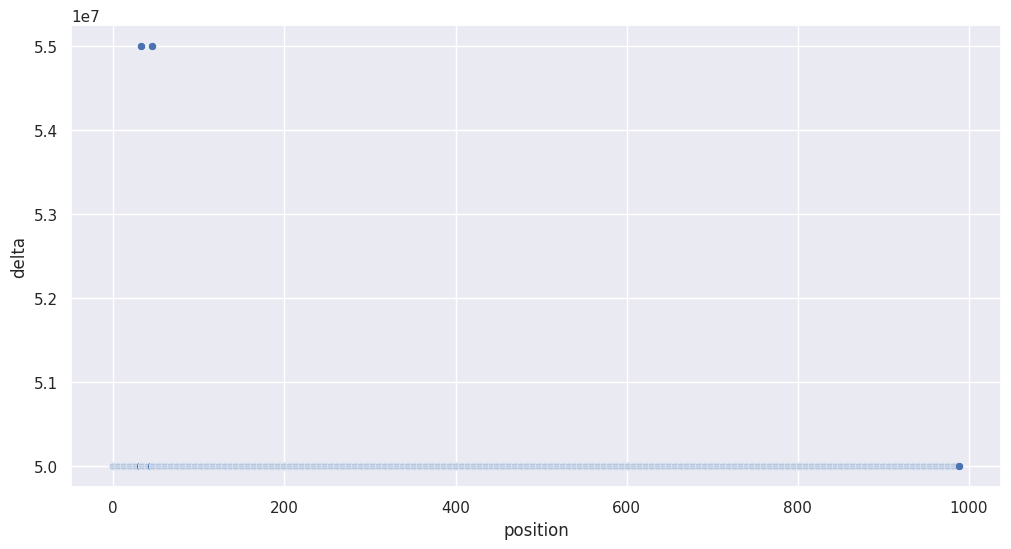

In [119]:
deltas = np.diff(df['#timestamp [ns]'])
delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
sns.set_theme(rc={'figure.figsize':(12, 6)})
sns.scatterplot(data=delta_df, x='position', y='delta')

In [120]:
delta_df.describe()

,position,delta
count,989.000000,9.890000e+02
mean,494.000000,5.001010e+07
std,285.644009,2.247136e+05
min,0.000000,4.999885e+07
25%,247.000000,4.999987e+07
50%,494.000000,4.999987e+07
75%,741.000000,5.000013e+07
max,988.000000,5.500006e+07


In [121]:
pd.set_option('display.max_rows', 500)

In [122]:
delta_df['delta'].unique()

array([49999104, 50003968, 49999872, 50000384, 50000128, 55000064,
       50001152, 49998848, 50000896, 54999040])

In [123]:
delta_df[delta_df['delta']==55000064] = 50003968

In [124]:
delta_df[delta_df['delta']==54999040]=49999872

In [125]:
delta_df['delta'].unique()

array([49999104, 50003968, 49999872, 50000384, 50000128, 50001152,
       49998848, 50000896])

In [126]:
start_ts = df['#timestamp [ns]'].iloc[0]

In [127]:
adjusted_deltas = np.insert(delta_df['delta'], 0, start_ts, axis=0)

In [128]:
adjusted_deltas = modified_ts_arr = np.cumsum(adjusted_deltas)

In [129]:
len(adjusted_deltas)

990

In [130]:
df['#timestamp [ns]'] = adjusted_deltas

In [131]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   #timestamp [ns]  990 non-null    int64 
 1   filename         990 non-null    object
dtypes: int64(1), object(1)
memory usage: 15.6+ KB


In [134]:
df

,#timestamp [ns],filename
0,1738002422666883840,1738002422666883840.png
1,1738002422716882944,1738002422716882944.png
2,1738002422766886912,1738002422766886912.png
3,1738002422816886784,1738002422816886784.png
4,1738002422866887168,1738002422866887168.png
...,...,...
985,1738002471916879872,1738002471926875136.png
986,1738002471966879744,1738002471976875008.png
987,1738002472016879872,1738002472026875136.png
988,1738002472066879744,1738002472076875008.png


In [132]:
df.to_csv('/home/shiva/Datasets/V2_01_easy/V2_01_easy/mav0/cam0/data.csv', index=False)

In [133]:
import os
mappings = {}

for el in df.to_dict('records'):
    mappings[el['filename']] = el['#timestamp [ns]']

for filename in os.listdir(f'/home/shiva/Datasets/V2_01_easy/V2_01_easy/mav0/cam0/data'):
    if filename in mappings.keys():
        os.rename(f'/home/shiva/Datasets/V2_01_easy/V2_01_easy/mav0/cam0/data/{filename}', f'/home/shiva/Datasets/V2_01_easy/V2_01_easy/mav0/cam0/data/{mappings[filename]}.png')